# Cardiovascular Deasease Prediction

In this project, I apply different machine learning algorithms to the Cardiovascular Disease dataset, an open-source dataset containing clinical patient data.
The goal is to predict whether a patient is likely to develop cardiovascular disease based on clinical and lifestyle features.

In [1]:
# Load the required libraries
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline

In [3]:
from sklearn.metrics import classification_report, confusion_matrix, RocCurveDisplay, precision_recall_curve, roc_auc_score

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, StackingClassifier
from xgboost import XGBClassifier

import shap
shap.initjs()

### 1. EDA Phase

In [4]:
# Load dataset

data = pd.read_csv('cardio_train.csv', sep = ';')

data.head()

,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
0,0,18393,2,168,62.0,110,80,1,1,0,0,1,0
1,1,20228,1,156,85.0,140,90,3,1,0,0,1,1
2,2,18857,1,165,64.0,130,70,3,1,0,0,0,1
3,3,17623,2,169,82.0,150,100,1,1,0,0,1,1
4,4,17474,1,156,56.0,100,60,1,1,0,0,0,0


In [5]:
print(data.shape)
print(data.info())

(70000, 13)
<class 'pandas.DataFrame'>
RangeIndex: 70000 entries, 0 to 69999
Data columns (total 13 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   id           70000 non-null  int64  
 1   age          70000 non-null  int64  
 2   gender       70000 non-null  int64  
 3   height       70000 non-null  int64  
 4   weight       70000 non-null  float64
 5   ap_hi        70000 non-null  int64  
 6   ap_lo        70000 non-null  int64  
 7   cholesterol  70000 non-null  int64  
 8   gluc         70000 non-null  int64  
 9   smoke        70000 non-null  int64  
 10  alco         70000 non-null  int64  
 11  active       70000 non-null  int64  
 12  cardio       70000 non-null  int64  
dtypes: float64(1), int64(12)
memory usage: 6.9 MB
None


In [6]:
# change dataset index
data.set_index('id', inplace = True)

In [7]:
# 'age' column expressed in years
data['age_years'] = (data['age']/365.25).astype(int)
data = data.drop(columns = ['age']) #data.drop('age',axis = 1)
data.sample()

,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio,age_years
id,,,,,,,,,,,,
57812,1,163,72.0,150,90,1,1,0,0,0,1,55


In [8]:
# Check dataset statistics
# We can see outliers in ap_hi (systolic pressure) and ap_lo (diastolic pressure)
data.describe().T

,count,mean,std,min,25%,50%,75%,max
gender,70000.0,1.349571,0.476838,1.0,1.0,1.0,2.0,2.0
height,70000.0,164.359229,8.210126,55.0,159.0,165.0,170.0,250.0
weight,70000.0,74.205690,14.395757,10.0,65.0,72.0,82.0,200.0
ap_hi,70000.0,128.817286,154.011419,-150.0,120.0,120.0,140.0,16020.0
ap_lo,70000.0,96.630414,188.472530,-70.0,80.0,80.0,90.0,11000.0
cholesterol,70000.0,1.366871,0.680250,1.0,1.0,1.0,2.0,3.0
gluc,70000.0,1.226457,0.572270,1.0,1.0,1.0,1.0,3.0
smoke,70000.0,0.088129,0.283484,0.0,0.0,0.0,0.0,1.0
alco,70000.0,0.053771,0.225568,0.0,0.0,0.0,0.0,1.0
active,70000.0,0.803729,0.397179,0.0,1.0,1.0,1.0,1.0


In [9]:
# is target balanced?
data['cardio'].value_counts()

cardio
0    35021
1    34979
Name: count, dtype: int64

In [10]:
# Handle these outliers
# Give a more understandable name to the 2 features
data = data.rename(columns = {'ap_hi' : 'systolic_press', 'ap_lo': 'diastolic_press'})
data.sample()

,gender,height,weight,systolic_press,diastolic_press,cholesterol,gluc,smoke,alco,active,cardio,age_years
id,,,,,,,,,,,,
56984,1,168,82.0,100,60,2,3,0,0,0,1,54


In [11]:
# Let's consider that:
# 1- systolic pressure has acceptable values in the range 60-250
# 2- diastolic pressure has acceptable values in the range 40-200
# 3- systolic pressure > diastolic pressure

# logical inconsistency
inconsinstency = (data['systolic_press'] < data['diastolic_press']).sum()
print(f'Observations with systolic pressure < diastolic pressure : {inconsinstency}')
# quanti valori non plausibili per le pressioni
bad_systolic = ((data['systolic_press'] < 60) | (data['systolic_press'] > 250)).sum()
bad_diastolic = ((data['diastolic_press'] < 40) | (data['diastolic_press'] > 200)).sum()
print(f'Observations with inconsistency systolic pressure: {bad_systolic}')
print(f'Observations with inconsistency diastolic pressure: {bad_diastolic}')


Observations with systolic pressure < diastolic pressure : 1234
Observations with inconsistency systolic pressure: 228
Observations with inconsistency diastolic pressure: 1012


In [12]:
# keep only rows with physiologically plausible and logically consistent blood pressure , weith and hight valuues

data_clean = data[(data['systolic_press'] >= data['diastolic_press']) 
    & (data['systolic_press'].between(60,250)) 
    & (data['diastolic_press'].between(40,200))
    & (data['weight'].between(50,150))
    & (data['height'].between(140,200))].copy()

print(f'Rows before cleaning: {len(data)}')
print(f'Rows after cleaning: {len(data_clean)}')
print(f'Rows removed: {len(data) - len(data_clean)}')
print(f'Percentage removed: {(len(data) - len(data_clean)) / len(data) * 100:.2f}%')

#Since outliers represent only 3.55% of the entire dataset, removing them will not lead to any significant loss of information

Rows before cleaning: 70000
Rows after cleaning: 67514
Rows removed: 2486
Percentage removed: 3.55%


## 2. Feature Engineering

In [13]:
# evaluation of the Body Mass Index bmi = weight(kg)/hight(m)

data_clean['BMI'] = data_clean['weight']/(data_clean['height']/100)**2
data_clean['BMI'].describe().T

count    67514.000000
mean        27.534303
std          5.064610
min         14.577259
25%         23.875115
50%         26.438071
75%         30.189591
max         63.975402
Name: BMI, dtype: float64

In [14]:
# watching the BMI value stats, there are some inconsistent values
# Typically, the lower value range is 15–16 kg/m^2, while the upper range is 45–50 kg/m^2. These are the clinically plausible values.
# Therefore, to aligne with theese values, I chosed a range of 15-50 kg/m^2

bad_bmi = ((data_clean['BMI'] < 15) | (data_clean['BMI'] > 50)).sum()

# There are few observations that can be discarded
print(f' BMI logical inconsistent values: {bad_bmi}')

 BMI logical inconsistent values: 111


In [15]:
data_ready = data_clean[data_clean['BMI'].between(15,50)].copy()

print(f'Rows before cleaning: {len(data_clean)}')
print(f'Rows after cleaning: {len(data_ready)}')
print(f'Rows removed: {len(data_clean) - len(data_ready)}')
print(f'Percentage removed: {(len(data_clean) - len(data_ready)) / len(data_clean) * 100:.2f}%')

Rows before cleaning: 67514
Rows after cleaning: 67403
Rows removed: 111
Percentage removed: 0.16%


## 3. Graphical Visualization

In [16]:
# graphical relationship between target and features
# Cholesterol and glucose are reported as categorical levels rather than continuous values

cholesterol_rate = data_ready.groupby('cholesterol')['cardio'].mean()

print(f'Percentage of cholesterol group with vascular desease:\n{round(cholesterol_rate*100,2)}')

Percentage of cholesterol group with vascular desease:
cholesterol
1    43.81
2    60.02
3    76.34
Name: cardio, dtype: float64


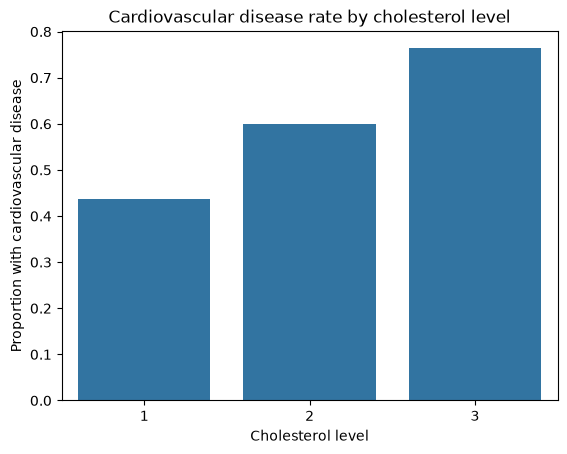

In [17]:
sns.barplot(x = cholesterol_rate.index, y = cholesterol_rate.values)
plt.xlabel('Cholesterol level')
plt.ylabel('Proportion with cardiovascular disease')
plt.title('Cardiovascular disease rate by cholesterol level')
plt.show()

In [18]:
# Cardiovascular disease rate by glucose level
glucose_rate = data_ready.groupby('gluc')['cardio'].mean()
glucose_rate

gluc
1    0.478492
2    0.590946
3    0.618565
Name: cardio, dtype: float64

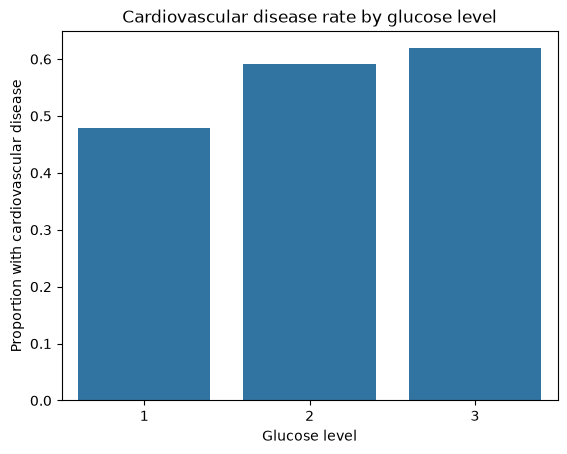

In [19]:
sns.barplot(x = glucose_rate.index, y = glucose_rate.values)
plt.xlabel('Glucose level')
plt.ylabel('Proportion with cardiovascular disease')
plt.title('Cardiovascular disease rate by glucose level')
plt.show()

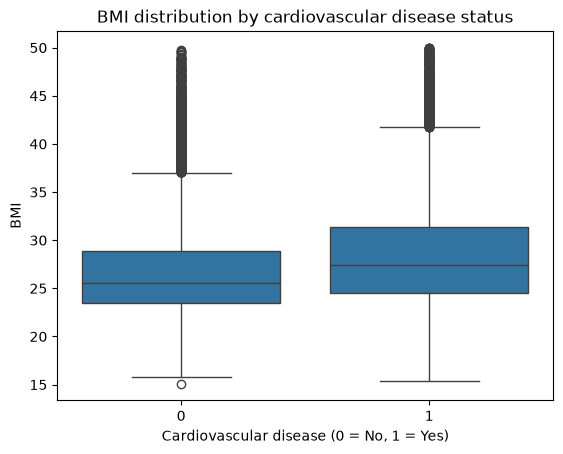

In [20]:
# BMI distribution by cardiovascular disease status
sns.boxplot(x='cardio', y='BMI', data=data_ready) #hue = 'gender'
plt.xlabel('Cardiovascular disease (0 = No, 1 = Yes)')
plt.ylabel('BMI')
plt.title('BMI distribution by cardiovascular disease status')
plt.show()

# The plot shows distinct median values and non-overlapping distributions, indicating that BMI is a strong predictive feature.
# Although a few outliers are present, in clinical settings they may represent patients in critical condition

<function matplotlib.pyplot.show(close=None, block=None)>

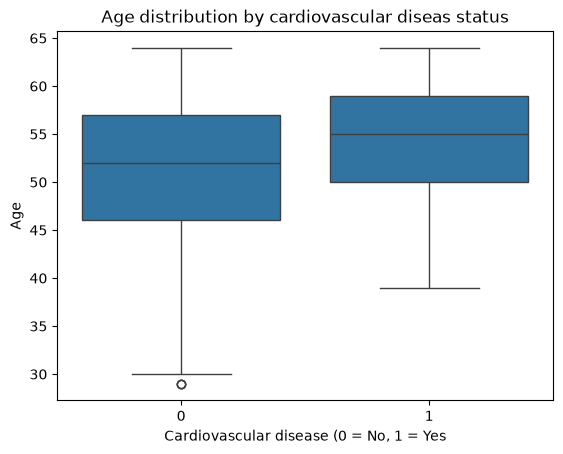

In [21]:
# Age distribution by cardiovascular disease status

sns.boxplot(data = data_ready, x = 'cardio', y = 'age_years')
plt.xlabel('Cardiovascular disease (0 = No, 1 = Yes')
plt.ylabel('Age')
plt.title('Age distribution by cardiovascular diseas status')
plt.show

# the different medians and non-overlapping distributions show that 'age' is a strong predictive feature

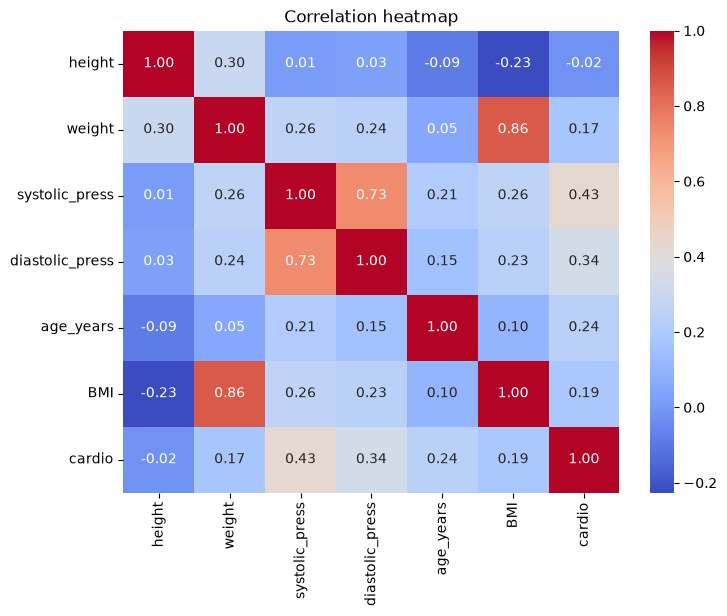

In [22]:
# correlation across numerical feauters
# glucose and cholesterol indicate levels

numerical_features = ['height','weight','systolic_press','diastolic_press','age_years','BMI','cardio']

corr = data_ready[numerical_features].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot = True, cmap = 'coolwarm', fmt = '.2f' )
plt.title('Correlation heatmap')
plt.show()

In [23]:
# The correlation matrix shows that:
# 1. There is a strong relationship between the target and features like pressure, BMI, and age
# 2. There is a strong correlation between BMI and weight
# Due to the clinical importance of BMI and its high collinearity with weight, I decided to drop weight

data_final = data_ready.drop(columns = ['weight']).copy()

## 4. Preprocessing

In [24]:
data_final.info()

<class 'pandas.DataFrame'>
Index: 67403 entries, 0 to 99999
Data columns (total 12 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   gender           67403 non-null  int64  
 1   height           67403 non-null  int64  
 2   systolic_press   67403 non-null  int64  
 3   diastolic_press  67403 non-null  int64  
 4   cholesterol      67403 non-null  int64  
 5   gluc             67403 non-null  int64  
 6   smoke            67403 non-null  int64  
 7   alco             67403 non-null  int64  
 8   active           67403 non-null  int64  
 9   cardio           67403 non-null  int64  
 10  age_years        67403 non-null  int64  
 11  BMI              67403 non-null  float64
dtypes: float64(1), int64(11)
memory usage: 6.7 MB


In [25]:
# split numerical and categorical features
numerical_features = ['height', 'systolic_press', 'diastolic_press', 'age_years', 'BMI']
categorical_features = ['gender', 'cholesterol', 'gluc', 'smoke', 'alco', 'active']

# split data and target
X = data_final.drop(columns = ['cardio'])
y = data_final['cardio']

# train_test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = .20, stratify = y, random_state = 42 )



In [26]:
# preprocess pipeline

numerical_pipeline = Pipeline(steps = [('scaler',StandardScaler())])

categorical_pipeline = Pipeline(steps = [('encoder',OneHotEncoder(drop = 'first'))])

preprocessor = ColumnTransformer(transformers = [('num',numerical_pipeline, numerical_features), 
                                                 ('cat',categorical_pipeline, categorical_features)])

# transformer check
preprocessor.fit(X_train)
print(preprocessor.get_feature_names_out())

['num__height' 'num__systolic_press' 'num__diastolic_press'
 'num__age_years' 'num__BMI' 'cat__gender_2' 'cat__cholesterol_2'
 'cat__cholesterol_3' 'cat__gluc_2' 'cat__gluc_3' 'cat__smoke_1'
 'cat__alco_1' 'cat__active_1']


## 5. Classification Models

#### 5.1 Logistic regression

In [27]:
# model pipeline definition
pipeline_lr = Pipeline(steps = [('preprocessor', preprocessor), 
                                ('logistic_regression', LogisticRegression(max_iter = 1000, random_state = 42))])

# Fit pipeline_lr
pipeline_lr.fit(X_train, y_train)

# get prediction and predicted probability for class 1
prediction_lr = pipeline_lr.predict(X_test)

proba_lr = pipeline_lr.predict_proba(X_test)[:,1]

# Baseline Model Performance
print('========== Logistic Regression Baseline Model Performance =========')
print(classification_report(y_test, prediction_lr))

========== Logistic Regression Baseline Model Performance =========
              precision    recall  f1-score   support

           0       0.70      0.79      0.74      6775
           1       0.76      0.67      0.71      6706

    accuracy                           0.73     13481
   macro avg       0.73      0.73      0.73     13481
weighted avg       0.73      0.73      0.73     13481



In [28]:
# baseline logistic regression (already done above)
# logistic regression with class_weight='balanced' to improve recall on class 1

pipeline_lr_balanced = Pipeline(steps = [('preprocessor', preprocessor), 
                                ('logistic_regression', LogisticRegression(max_iter = 1000, 
                                                                           random_state = 42, 
                                                                           class_weight = 'balanced'))])

pipeline_lr_balanced.fit(X_train, y_train)
prediction_lr_balanced = pipeline_lr_balanced.predict(X_test)

print('========== Logistic Regression (class_weight = balanced) Model Performance =========')
print(classification_report(y_test, prediction_lr_balanced))

========== Logistic Regression (class_weight = balanced) Model Performance =========
              precision    recall  f1-score   support

           0       0.71      0.79      0.74      6775
           1       0.76      0.67      0.71      6706

    accuracy                           0.73     13481
   macro avg       0.73      0.73      0.73     13481
weighted avg       0.73      0.73      0.73     13481



In [29]:
# Function definition to compare ROC curve and Precision-Recall curve

def plot_roc_and_pr_curve(y_true, y_prob, model_name):
    """Plot ROC curve and precision-recall trade-off vs threshold for a given model."""

    fig, axes = plt.subplots(1,2, figsize = (14,5))

    # plot Roc curve
    RocCurveDisplay.from_predictions(y_true, y_prob, ax = axes[0])
    axes[0].set_title(f'ROC curve - {model_name}')

    # plot Precision-Recall curve
    precision, recall, threshold = precision_recall_curve(y_true, y_prob)

    axes[1].plot(threshold, precision[:-1], label = 'Precision')
    axes[1].plot(threshold, recall[:-1], label = 'Recall')
    axes[1].set_xlabel('Threshold')
    axes[1].set_ylabel('Score')
    axes[1].legend()
    axes[1].set_title(f'Precision-Recall trade-off - {model_name}')

    plt.tight_layout()
    plt.show()

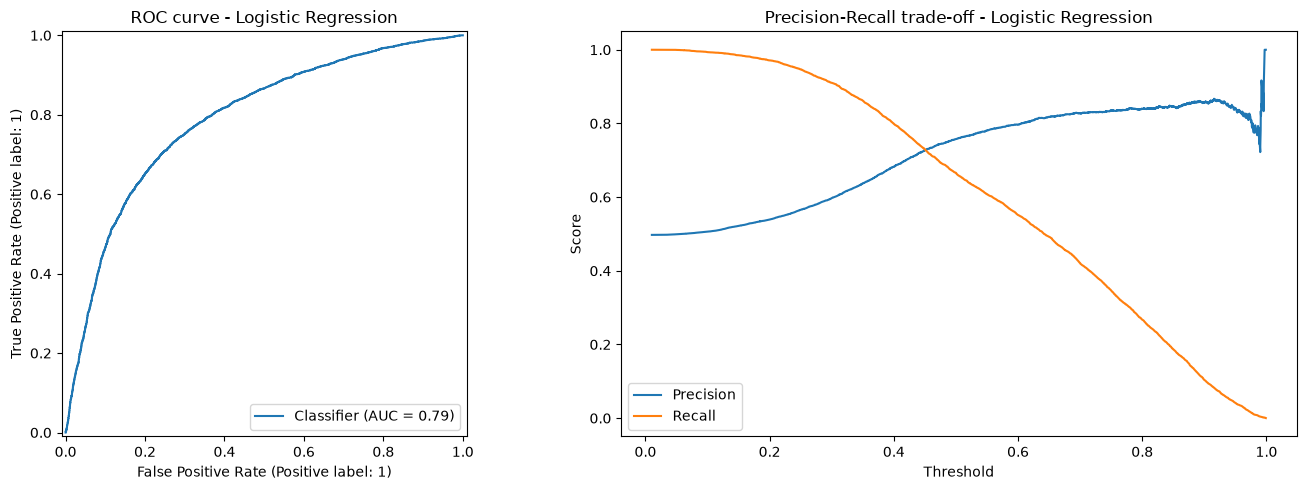

In [30]:
# Since the dataset is well-balanced, setting class_weight to 'balanced' has no significant impact on model performance
# Therefore, I am going to tune the model threshold for better performance
# now I am plotting the ROC curve and Precision-Recall curve in order to choose the best threshold, using the custom fuction defined above

plot_roc_and_pr_curve(y_test, proba_lr, 'Logistic Regression')
                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                          

In [31]:
# ROC curve has AUC = 0.79
auc_lr = roc_auc_score(y_test, proba_lr)
# The P-R curve suggests a threshold value below 0.45 to improve Recall; testing with threshold = 0.4
pred_lr_lower_threshold = (proba_lr > 0.4).astype(int)

print('========== Logistic Regression (Threshold = 0.4) Model Performance =========')
print(classification_report(y_test, pred_lr_lower_threshold))
print(f'Linear Regression auc: {auc_lr:.2f}')


========== Logistic Regression (Threshold = 0.4) Model Performance =========
              precision    recall  f1-score   support

           0       0.76      0.63      0.69      6775
           1       0.68      0.80      0.74      6706

    accuracy                           0.72     13481
   macro avg       0.72      0.72      0.71     13481
weighted avg       0.72      0.72      0.71     13481

Linear Regression auc: 0.79


#### 5.2 Random Forest

========== Random Forest Baseline Model Performance =========
              precision    recall  f1-score   support

           0       0.70      0.72      0.71      6775
           1       0.71      0.69      0.70      6706

    accuracy                           0.70     13481
   macro avg       0.70      0.70      0.70     13481
weighted avg       0.70      0.70      0.70     13481

Random Forest Baseline auc: 0.76


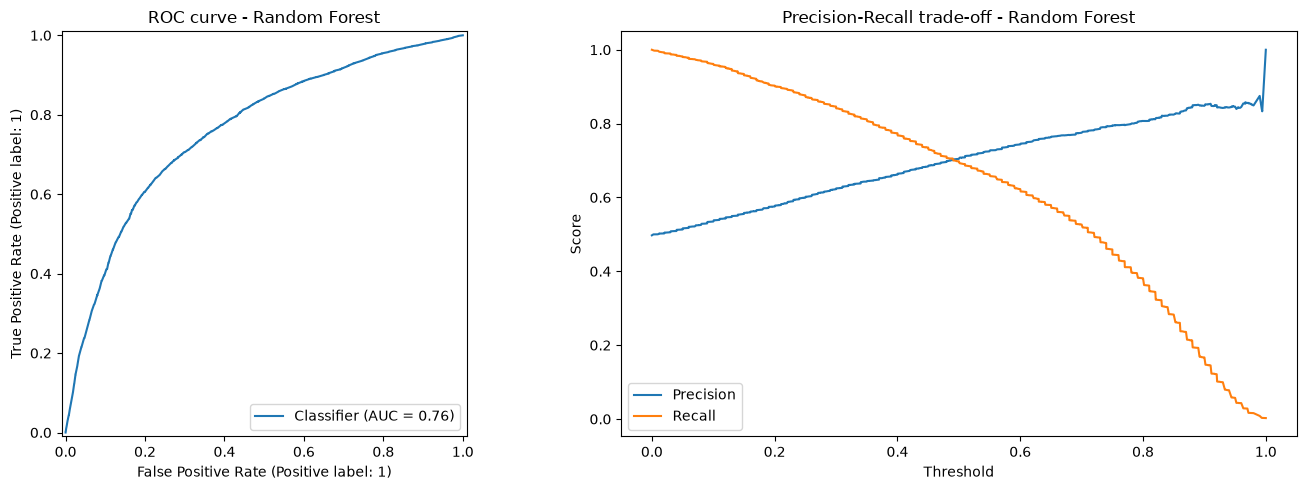

In [32]:
# Random Forest Pipeline

pipeline_rf = Pipeline(steps = [('preprocessor',preprocessor), 
                                ('random_forest', RandomForestClassifier(n_estimators = 100, random_state = 42))])

# fit model
pipeline_rf.fit(X_train, y_train)

# get prediction and predicted probability for class 1
prediction_rf = pipeline_rf.predict(X_test)

proba_rf = pipeline_rf.predict_proba(X_test)[:,1]

auc_rf = roc_auc_score(y_test, proba_rf)

# Baseline Model Performance
print('========== Random Forest Baseline Model Performance =========')
print(classification_report(y_test, prediction_rf))
print(f'Random Forest Baseline auc: {auc_rf:.2f}')

# Plot ROC curve and Precion-Recall curve
plot_roc_and_pr_curve(y_test, proba_rf, 'Random Forest')

In [33]:
# test overfitting -> train accuracy vs test accuracy
print(f'Random Forest train accuracy: {pipeline_rf.score(X_train, y_train):.2f}')
print(f'Random Forest test accuracy: {pipeline_rf.score(X_test, y_test):.2f}')

Random Forest train accuracy: 0.98
Random Forest test accuracy: 0.70


In [34]:
# Random Forest hyperparameter tuning

grid_params = {
    'random_forest__max_depth': [5, 10, 15, None], 
    'random_forest__min_samples_leaf': [1, 5, 10], 
    'random_forest__n_estimators': [100, 200, 300]
}

grid_search = GridSearchCV(
    estimator = pipeline_rf,
    param_grid = grid_params,
    cv = 5,
    scoring = 'roc_auc',
    n_jobs = -1
)

grid_search.fit(X_train, y_train)

print(f'Best parameters: {grid_search.best_params_}')
print(f'Best cross-validated AUC score: {grid_search.best_score_:.2f}')


Best parameters: {'random_forest__max_depth': 15, 'random_forest__min_samples_leaf': 10, 'random_forest__n_estimators': 300}
Best cross-validated AUC score: 0.80


Tuned Random Forest train accuracy: 0.76
Tuned Random Forest test accuracy: 0.73



========== Random Forest Tuned Model Performance =========
              precision    recall  f1-score   support

           0       0.71      0.79      0.75      6775
           1       0.76      0.68      0.72      6706

    accuracy                           0.73     13481
   macro avg       0.74      0.73      0.73     13481
weighted avg       0.74      0.73      0.73     13481

Random Forest Tuned auc : 0.80


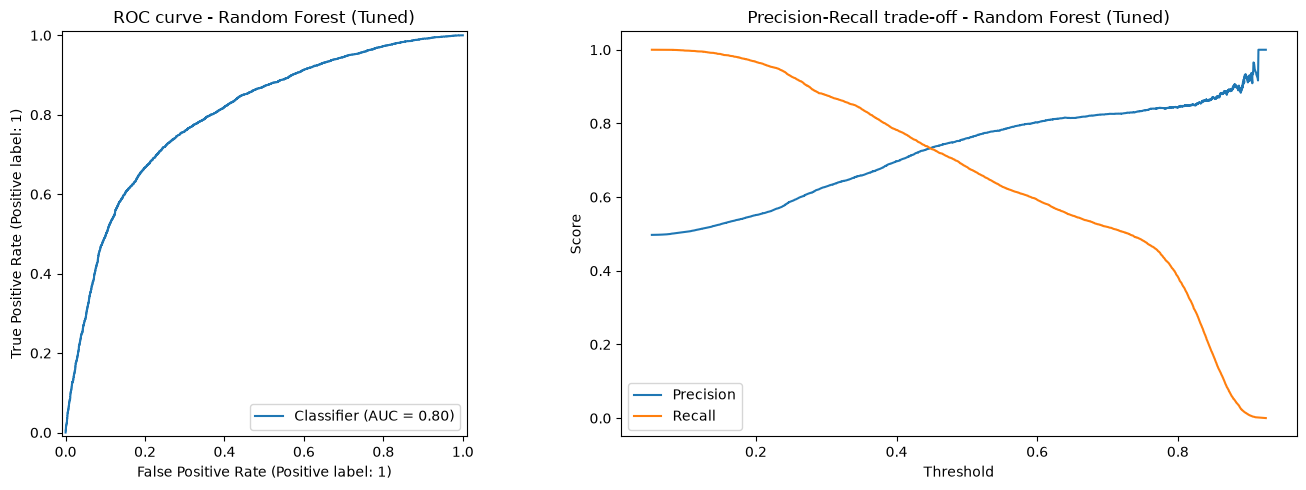

In [35]:
# use the best estimator found by grid search
best_rf = grid_search.best_estimator_

# check overfitting
print(f'Tuned Random Forest train accuracy: {best_rf.score(X_train, y_train):.2f}')
print(f'Tuned Random Forest test accuracy: {best_rf.score(X_test, y_test):.2f}')
print('\n\n')

# also get updated classification report and probabilities
pred_rf_tuned = best_rf.predict(X_test)
proba_rf_tuned = best_rf.predict_proba(X_test)[:, 1]
auc_rf_tuned = roc_auc_score(y_test, proba_rf_tuned)

print('========== Random Forest Tuned Model Performance =========')
print(classification_report(y_test, pred_rf_tuned))
print(f'Random Forest Tuned auc : {auc_rf_tuned:.2f}')

plot_roc_and_pr_curve(y_test, proba_rf_tuned, 'Random Forest (Tuned)')

In [36]:
# ROC curve has AUC = 0.80
# The P-R curve suggests a threshold value below 0.45 to improve Recall; testing with threshold = 0.4

pred_rf_tuned_lower_threshold = (proba_rf_tuned >= 0.4).astype(int)

print('========== Random Forest Tuned (Threshold = 0.4) Model Performance =========')
print(classification_report(y_test, pred_rf_tuned_lower_threshold))

========== Random Forest Tuned (Threshold = 0.4) Model Performance =========
              precision    recall  f1-score   support

           0       0.75      0.66      0.71      6775
           1       0.70      0.78      0.74      6706

    accuracy                           0.72     13481
   macro avg       0.73      0.72      0.72     13481
weighted avg       0.73      0.72      0.72     13481



#### 5.3 XG Boost

========== XGB Baseline Model Performance =========
              precision    recall  f1-score   support

           0       0.71      0.77      0.74      6775
           1       0.75      0.68      0.72      6706

    accuracy                           0.73     13481
   macro avg       0.73      0.73      0.73     13481
weighted avg       0.73      0.73      0.73     13481

XGB Classifier auc : 0.79





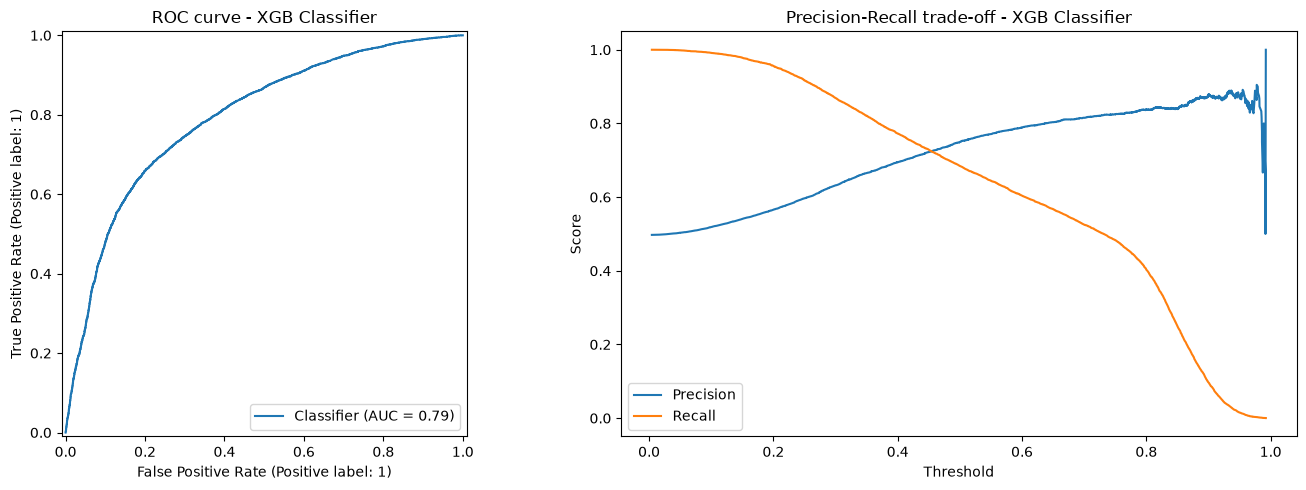

In [37]:
# xgb pipeline
pipeline_xgb = Pipeline(steps = [('preprocessor', preprocessor), 
                                 ('xgb', XGBClassifier(n_estimators = 100, 
                                                      eval_metric = 'logloss', 
                                                      random_state = 42))]) # objective = 'binary:logistic' default value
# fit model
pipeline_xgb.fit(X_train, y_train)

# get prediction and predicted probability for class 1
pred_xgb = pipeline_xgb.predict(X_test)
proba_xgb = pipeline_xgb.predict_proba(X_test)[:,1]
auc_xgb = roc_auc_score(y_test, proba_xgb)

print('========== XGB Baseline Model Performance =========')
print(classification_report(y_test, pred_xgb))
print(f'XGB Classifier auc : {auc_xgb:.2f}')
print('\n\n')
plot_roc_and_pr_curve(y_test, proba_xgb, 'XGB Classifier')

In [38]:
# check overfitting
print(f'XGB train accuracy: {pipeline_xgb.score(X_train, y_train):.2f}')
print(f'XGB test accuracy: {pipeline_xgb.score(X_test, y_test):.2f}')

XGB train accuracy: 0.76
XGB test accuracy: 0.73


In [39]:
# XGB Classifier shows no significant overfitting and achieves similar performance to Logistic Regression and Random Forest
# Running a narrow hyperparameter search

grid_params_xgb = {
    'xgb__n_estimators': [50, 100, 200, 500],
    'xgb__learning_rate': [0.001, 0.01, 0.1, 0.3], 
    'xgb__max_depth': [3, 6, 9]
}

grid_search_xgb = GridSearchCV(
    estimator = pipeline_xgb,
    param_grid = grid_params_xgb,
    cv = 5,
    scoring = 'roc_auc',
    n_jobs = -1
)

grid_search_xgb.fit(X_train, y_train)

print(f'Best parameters: {grid_search_xgb.best_params_}')
print(f'Best cross-validated AUC score: {grid_search_xgb.best_score_:.2f}')

Best parameters: {'xgb__learning_rate': 0.1, 'xgb__max_depth': 3, 'xgb__n_estimators': 200}
Best cross-validated AUC score: 0.80


XGB tuned train accuracy: 0.74
XGB tuned test accuracy: 0.74
========== XGB Tuned Model Performance =========
              precision    recall  f1-score   support

           0       0.72      0.78      0.75      6775
           1       0.76      0.69      0.72      6706

    accuracy                           0.74     13481
   macro avg       0.74      0.74      0.73     13481
weighted avg       0.74      0.74      0.73     13481

XGB Tuned auc : 0.80





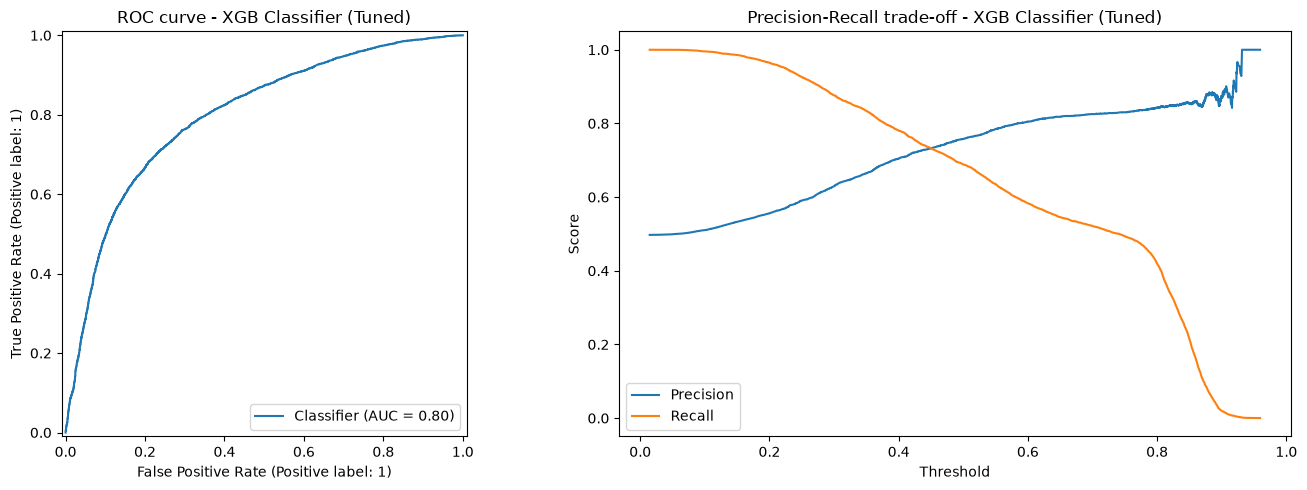

In [40]:
# use grid search results

best_xgb = grid_search_xgb.best_estimator_ 

# check overfitting
print(f'XGB tuned train accuracy: {best_xgb.score(X_train, y_train):.2f}')
print(f'XGB tuned test accuracy: {best_xgb.score(X_test, y_test):.2f}')

# get probbility and prediction again

pred_xgb_tuned = best_xgb.predict(X_test)
proba_xgb_tuned = best_xgb.predict_proba(X_test)[:,1]
auc_xgb_tuned = roc_auc_score(y_test, proba_xgb_tuned)

print('========== XGB Tuned Model Performance =========')
print(classification_report(y_test, pred_xgb_tuned))
print(f'XGB Tuned auc : {auc_xgb_tuned:.2f}')
print('\n\n')
plot_roc_and_pr_curve(y_test, proba_xgb_tuned, 'XGB Classifier (Tuned)')

#### 5.4 Stacking Classifier

In [41]:
# Try out a Stacking Classifier model

models = [('lr', pipeline_lr), ('rf', best_rf), ('xgb', best_xgb)]

stacking_clf = StackingClassifier(estimators = models, 
                                 final_estimator = LogisticRegression(max_iter = 1000, random_state = 42),
                                 cv = 5
                                 )
# fit and performance evaluation
stacking_clf.fit(X_train, y_train)

pred_stack = stacking_clf.predict(X_test)
proba_stack = stacking_clf.predict_proba(X_test)[:,1]
auc_stack = roc_auc_score(y_test, proba_stack)

print('========== Stacking Classifier Performance ==========')
print(classification_report(y_test, pred_stack))
print(f'Stacking AUC: {auc_stack:.2f}')

========== Stacking Classifier Performance ==========
              precision    recall  f1-score   support

           0       0.72      0.78      0.75      6775
           1       0.76      0.69      0.72      6706

    accuracy                           0.74     13481
   macro avg       0.74      0.74      0.74     13481
weighted avg       0.74      0.74      0.74     13481

Stacking AUC: 0.80


# 6. Features Interpretability (SHAP)

I will now proceed to the feature interpretability phase. I am using XGBoost as the baseline model, as it offers a good trade-off between performance and generalization.


In [42]:
# create a dedicated preprocessor without drop='first' for interpretability purposes
# tree-based models like XGBoost don't suffer from multicollinearity, so full one-hot encoding is safe here

categorical_pipeline_full = Pipeline(steps = [('encoder', OneHotEncoder())])

preprocessor_full = ColumnTransformer(transformers = [('num',numerical_pipeline, numerical_features), 
                                                       ('cat',categorical_pipeline_full, categorical_features)])

# strip the pipeline step prefix ('XGB__') from best_params_ keys
best_params_clean = {k.replace('xgb__', ''): v for k, v in grid_search_xgb.best_params_.items()}

# refit XGBoost with the best found hyperparameters, using the full encoding
pipeline_xgb_full = Pipeline(steps = [('preprocessor', preprocessor_full), 
                                 ('xgb', XGBClassifier(**best_params_clean, random_state = 42, eval_metric = 'logloss'))])

pipeline_xgb_full.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('xgb', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](11,)","['gender','height','systolic_press',...,'active','age_years','BMI']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,11
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remain

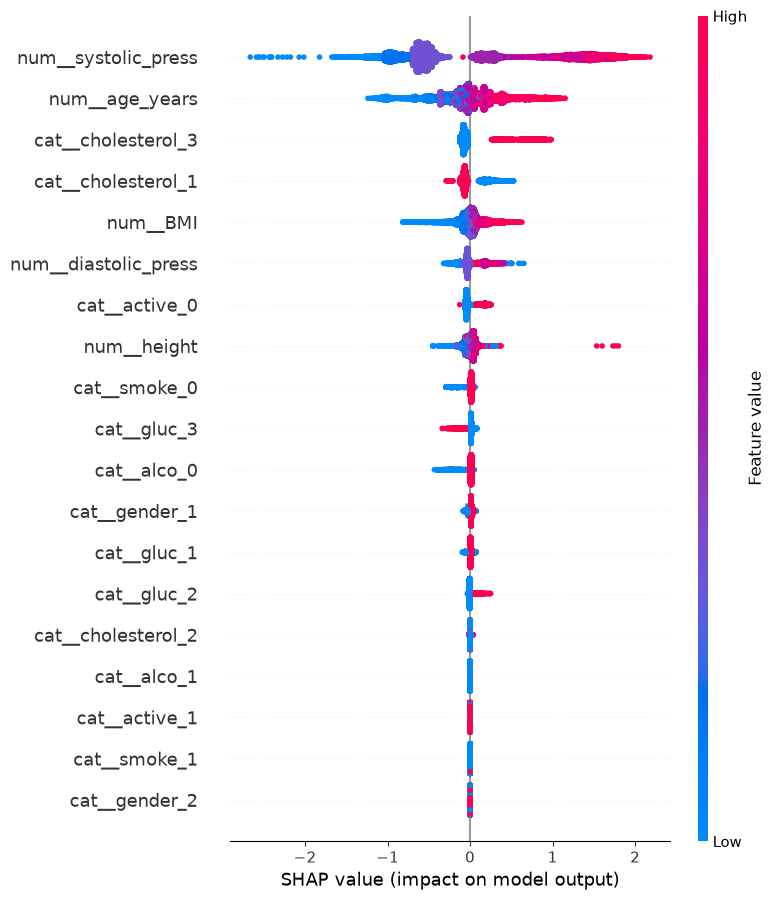

In [43]:
# TreeExplainer is optimized for tree-based models like XGBoost
explainer = shap.TreeExplainer(pipeline_xgb_full.named_steps['xgb'])

# transform test data using the same preprocessor first
X_test_transformed = pipeline_xgb_full.named_steps['preprocessor'].transform(X_test)

shap_values = explainer.shap_values(X_test_transformed)

# get the feature names after preprocessing (numerical + one-hot encoded categorical)
feature_names = pipeline_xgb_full.named_steps['preprocessor'].get_feature_names_out()

# summary plot: overall feature importance + direction of impact
shap.summary_plot(shap_values, X_test_transformed, feature_names = feature_names, show = False)

# save shap values plot
plt.savefig('shap_summary_xgb.png', dpi=300, bbox_inches='tight')
plt.show()

In [44]:
# find a high-risk and a low-risk patient according to the model

proba_xgb_full = pipeline_xgb_full.predict_proba(X_test)[:,1]

high_risk_idx = proba_xgb_full.argmax()
low_risk_idx = proba_xgb_full.argmin()

print(f'Highest predicted risk: {proba_xgb_full[high_risk_idx]:.2f}')
print(f'Lowest predicted risk: {proba_xgb_full[low_risk_idx]:.2f}')

Highest predicted risk: 0.96
Lowest predicted risk: 0.01


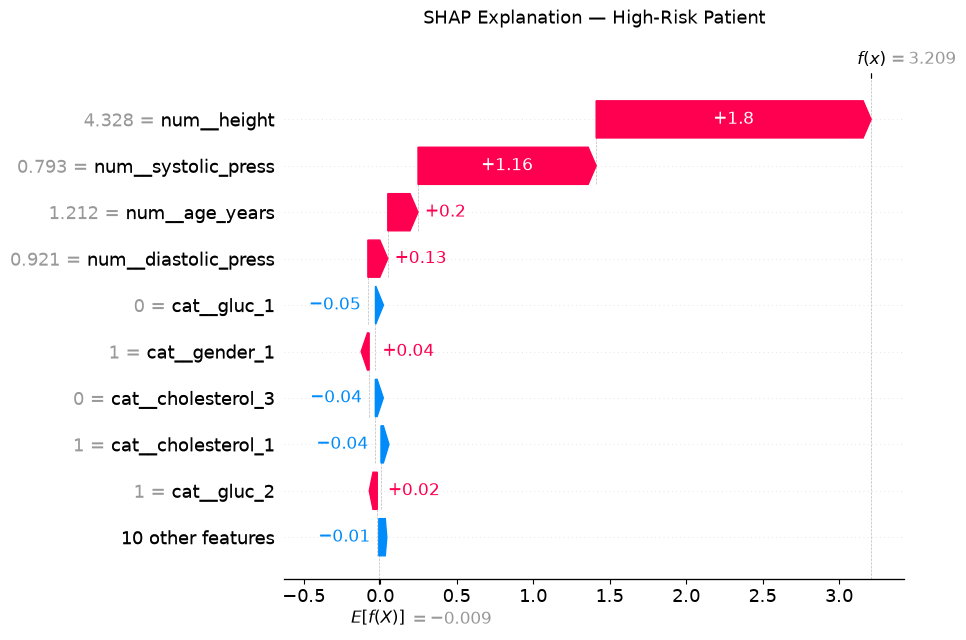

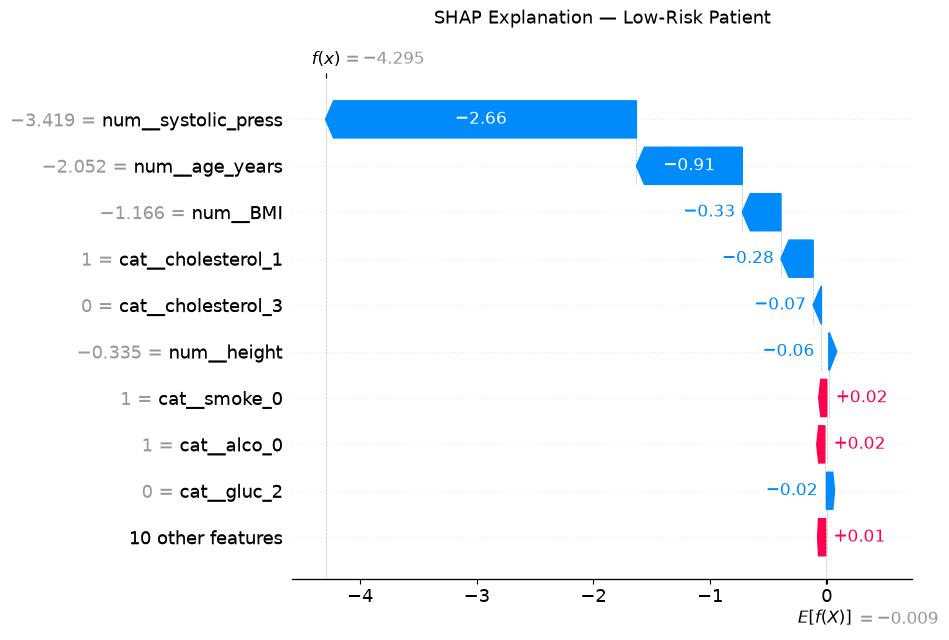

In [45]:
# waterfall plot for a single prediction — needs a shap.Explanation object, not raw shap_values
explanation_high_risk = shap.Explanation(
    values=shap_values[high_risk_idx],
    base_values=explainer.expected_value,
    data=X_test_transformed[high_risk_idx],
    feature_names=feature_names
)

shap.waterfall_plot(explanation_high_risk, show=False)

# plot and save figure
fig = plt.gcf()
ax = plt.gca()

ax.set_title('SHAP Explanation — High-Risk Patient', fontsize=13, pad=20)
plt.show()
fig.canvas.draw()
fig.savefig('shap_waterfall_high_risk.png', dpi=300, bbox_inches='tight')
plt.close(fig)


explanation_low_risk = shap.Explanation(
    values=shap_values[low_risk_idx],
    base_values=explainer.expected_value,
    data=X_test_transformed[low_risk_idx],
    feature_names=feature_names
)

shap.waterfall_plot(explanation_low_risk, show=False)

fig = plt.gcf()
ax = plt.gca()

ax.set_title('SHAP Explanation — Low-Risk Patient', fontsize=13, pad=20)
plt.show()
fig.canvas.draw()
fig.savefig('shap_waterfall_low_risk.png', dpi=300, bbox_inches='tight')
plt.close(fig)

## 7. Conclusion

This project explored prediction of cardiovascular disease using clinical and lyfestyle patient data,
comparing three different machine learning algorithms: Logistic Regression, Random Forest and XGBoost.

**Key findings**

- After data cleaning (removing ~3.7% of records with physiologically unlikely values) and feature engineering (BMI calculation), all three models converged to similar performance (AUC ≈ 0.79-0.80), suggesting that the manin limiting factor is the information contained in the available features rather than model complexity.
- A stacking ensemble of all three models did not outperforme the individial tuned algorithms, further confirming this hypothesis.
- SHAP analysis identified systolic blood pressure, age and cholesterol level as the strongest predictors of cardiovascular disease risk, consisten with established clinical knowledge (a reassuring sign of data quality and model reliability).
- Given the clinical context, model evaluation prioritized recall metric for the positive class over raw accuracy, since a missing true positive case (a false negative) carries a higher cost than a false alarm.

**Limitation**

- The dataset relies on self-reported data wich may introduce noise (as observed in outlier values requiring cleaning).
- Only basic clinical and lifestyle features were available, perhaps more advanced clinical markers (ECG, imaging data) could likely improve predictive performance.

**Final model**

XGBoost (tuned) was selected as the final model, offering the best trade off between performance, generalizations(no significant overfitting) and interpretability through SHAP.


